In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [37]:


np.random.seed(42)

# Create base dataset (100 rows)
n = 100

data = {
    'Age': np.random.randint(20, 50, n).astype(float),          # will make ~4% missing
    'Salary': np.random.randint(30000, 80000, n).astype(float), # will make ~6% missing
    'Experience': np.random.randint(1, 10, n).astype(float),    # will make ~2% missing
    'City': np.random.choice(['Delhi', 'Mumbai', 'Chennai'], n) # will make ~10% missing
}

df = pd.DataFrame(data)




In [38]:
df

,Age,Salary,Experience,City
0,26.0,67065.0,9.0,Chennai
1,39.0,56557.0,7.0,Delhi
2,48.0,63763.0,1.0,Mumbai
3,34.0,62606.0,1.0,Mumbai
4,30.0,41534.0,9.0,Chennai
...,...,...,...,...
95,48.0,72941.0,8.0,Mumbai
96,37.0,51834.0,6.0,Chennai
97,45.0,48047.0,8.0,Delhi
98,31.0,56105.0,1.0,Mumbai


In [39]:
# 🔹 Add missing values manually

# Age → 4% missing (4 rows)
df.loc[np.random.choice(n, 4, replace=False), 'Age'] = np.nan

# Salary → 6% missing (6 rows)
df.loc[np.random.choice(n, 6, replace=False), 'Salary'] = np.nan

# Experience → 2% missing (2 rows)
df.loc[np.random.choice(n, 2, replace=False), 'Experience'] = np.nan

# City → 10% missing (10 rows)
df.loc[np.random.choice(n, 10, replace=False), 'City'] = np.nan



In [40]:
# 🔹 Check missing %
missing_percent = df.isnull().mean() * 100




In [41]:
missing_percent

,0
Age,4.0
Salary,6.0
Experience,2.0
City,10.0


In [42]:
df.head()

,Age,Salary,Experience,City
0,26.0,67065.0,9.0,Chennai
1,NaN,56557.0,7.0,Delhi
2,48.0,63763.0,1.0,Mumbai
3,34.0,62606.0,1.0,Mumbai
4,30.0,41534.0,9.0,Chennai


In [43]:
df.shape

(100, 4)

In [44]:

df['City'].value_counts()

,count
City,
Delhi,32
Mumbai,31
Chennai,27


In [45]:
# Columns with <5% missing
cols_safe = df.columns[df.isnull().mean() < 0.05]

# Apply CCA only on those columns
df_cca = df.dropna(subset=cols_safe)


In [46]:
df_cca


,Age,Salary,Experience,City
0,26.0,67065.0,9.0,Chennai
2,48.0,63763.0,1.0,Mumbai
3,34.0,62606.0,1.0,Mumbai
4,30.0,41534.0,9.0,Chennai
5,27.0,NaN,9.0,Mumbai
...,...,...,...,...
95,48.0,72941.0,8.0,Mumbai
96,37.0,51834.0,6.0,Chennai
97,45.0,48047.0,8.0,Delhi
98,31.0,56105.0,1.0,Mumbai


In [63]:
print("Shape after selective CCA:", df_cca.shape)

Shape after selective CCA: (94, 4)


<Axes: >

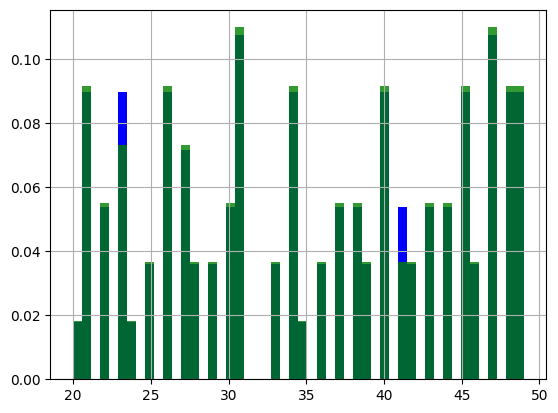

In [65]:
fig = plt.figure()
ax = fig.add_subplot(111)
df['Age'].hist(bins=50, ax=ax, density=True, color='blue')
df_cca['Age'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.8)

<Axes: ylabel='Density'>

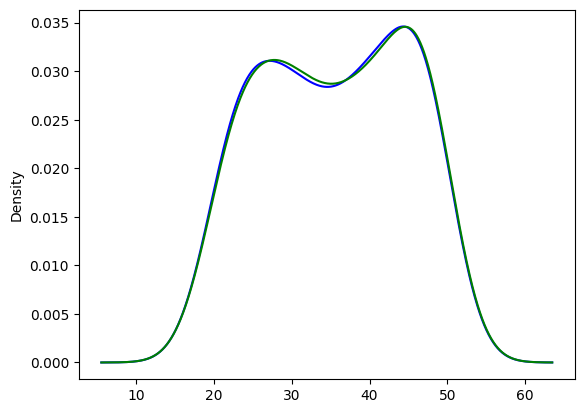

In [66]:
fig = plt.figure()
ax = fig.add_subplot(111)
df['Age'].plot.density(color='blue')
df_cca['Age'].plot.density(color='green')


<Axes: >

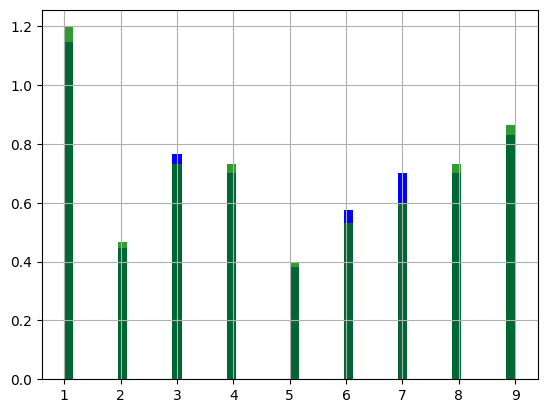

In [67]:
fig = plt.figure()
ax = fig.add_subplot(111)
df['Experience'].hist(bins=50, ax=ax, density=True, color='blue')
df_cca['Experience'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.8)

<Axes: ylabel='Density'>

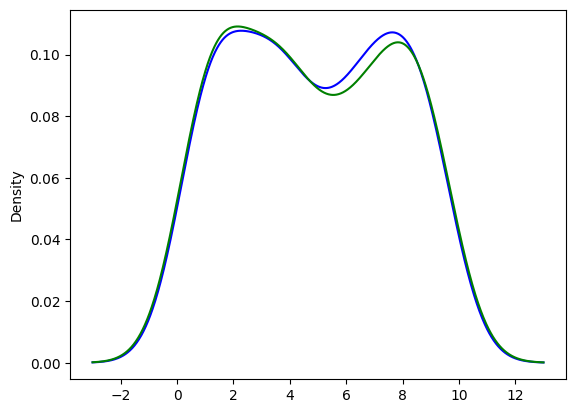

In [68]:
fig = plt.figure()
ax = fig.add_subplot(111)
df['Experience'].plot.density(color='blue')
df_cca['Experience'].plot.density(color='green')


In [72]:
ageCCA = pd.concat([
            df['Age'].value_counts() / len(df),
            df_cca['Age'].value_counts() / len(df_cca)
        ],
        axis=1)
ageCCA.columns = ['Before CCA', 'After cca']

ageCCA

,Before CCA,After cca
Age,,
31.0,0.06,0.063830
47.0,0.06,0.063830
34.0,0.05,0.053191
48.0,0.05,0.053191
26.0,0.05,0.053191
23.0,0.05,0.042553
49.0,0.05,0.053191
45.0,0.05,0.053191
40.0,0.05,0.053191


In [73]:
experienceCCA = pd.concat([
            df['Experience'].value_counts() / len(df),
            df_cca['Experience'].value_counts() / len(df_cca)
        ],
        axis=1)
experienceCCA.columns = ['Before CCA', 'After cca']

experienceCCA

,Before CCA,After cca
Experience,,
1.0,0.18,0.191489
9.0,0.13,0.138298
3.0,0.12,0.117021
7.0,0.11,0.095745
4.0,0.11,0.117021
8.0,0.11,0.117021
6.0,0.09,0.085106
2.0,0.07,0.074468
5.0,0.06,0.063830
